# Regresão linear simples

In [3]:
import kagglehub

path = kagglehub.dataset_download("lucass0s0/polycystic-ovary-syndrome-pcos")
print("Path to dataset files:", path)

Path to dataset files: /home/michel/.cache/kagglehub/datasets/lucass0s0/polycystic-ovary-syndrome-pcos/versions/1


In [4]:

import pandas as pd
dataset = pd.read_csv(path + '/pcos_rotterdam_balanceado.csv')

In [5]:
import numpy as np
np.random.seed(42)
import os

In [6]:
dataset.shape

(3000, 6)

In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        3000 non-null   int64  
 1   BMI                        3000 non-null   float64
 2   Menstrual_Irregularity     3000 non-null   int64  
 3   Testosterone_Level(ng/dL)  3000 non-null   float64
 4   Antral_Follicle_Count      3000 non-null   int64  
 5   PCOS_Diagnosis             3000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 140.8 KB


In [8]:
set(dataset["Age"])

{18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44}

In [9]:
dataset["Age"].value_counts()

Age
30    145
33    140
18    139
25    127
29    125
20    125
21    125
31    125
34    125
24    122
22    120
19    118
35    116
28    116
32    113
23    112
27    110
26    105
38    102
42     98
37     94
41     89
39     88
44     84
36     83
40     77
43     77
Name: count, dtype: int64

In [10]:
dataset.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,30.052667,23.646000,0.289333,57.228267,10.732333,0.200000
std,7.549982,4.510006,0.453529,18.171066,8.471478,0.400067
min,18.000000,8.500000,0.000000,20.500000,3.000000,0.000000
25%,24.000000,20.800000,0.000000,45.200000,5.000000,0.000000
50%,30.000000,23.400000,0.000000,53.200000,8.000000,0.000000
75%,36.000000,26.300000,1.000000,64.100000,11.000000,0.000000
max,44.000000,44.700000,1.000000,136.400000,39.000000,1.000000


array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Menstrual_Irregularity'}>,
        <Axes: title={'center': 'Testosterone_Level(ng/dL)'}>],
       [<Axes: title={'center': 'Antral_Follicle_Count'}>,
        <Axes: title={'center': 'PCOS_Diagnosis'}>]], dtype=object)

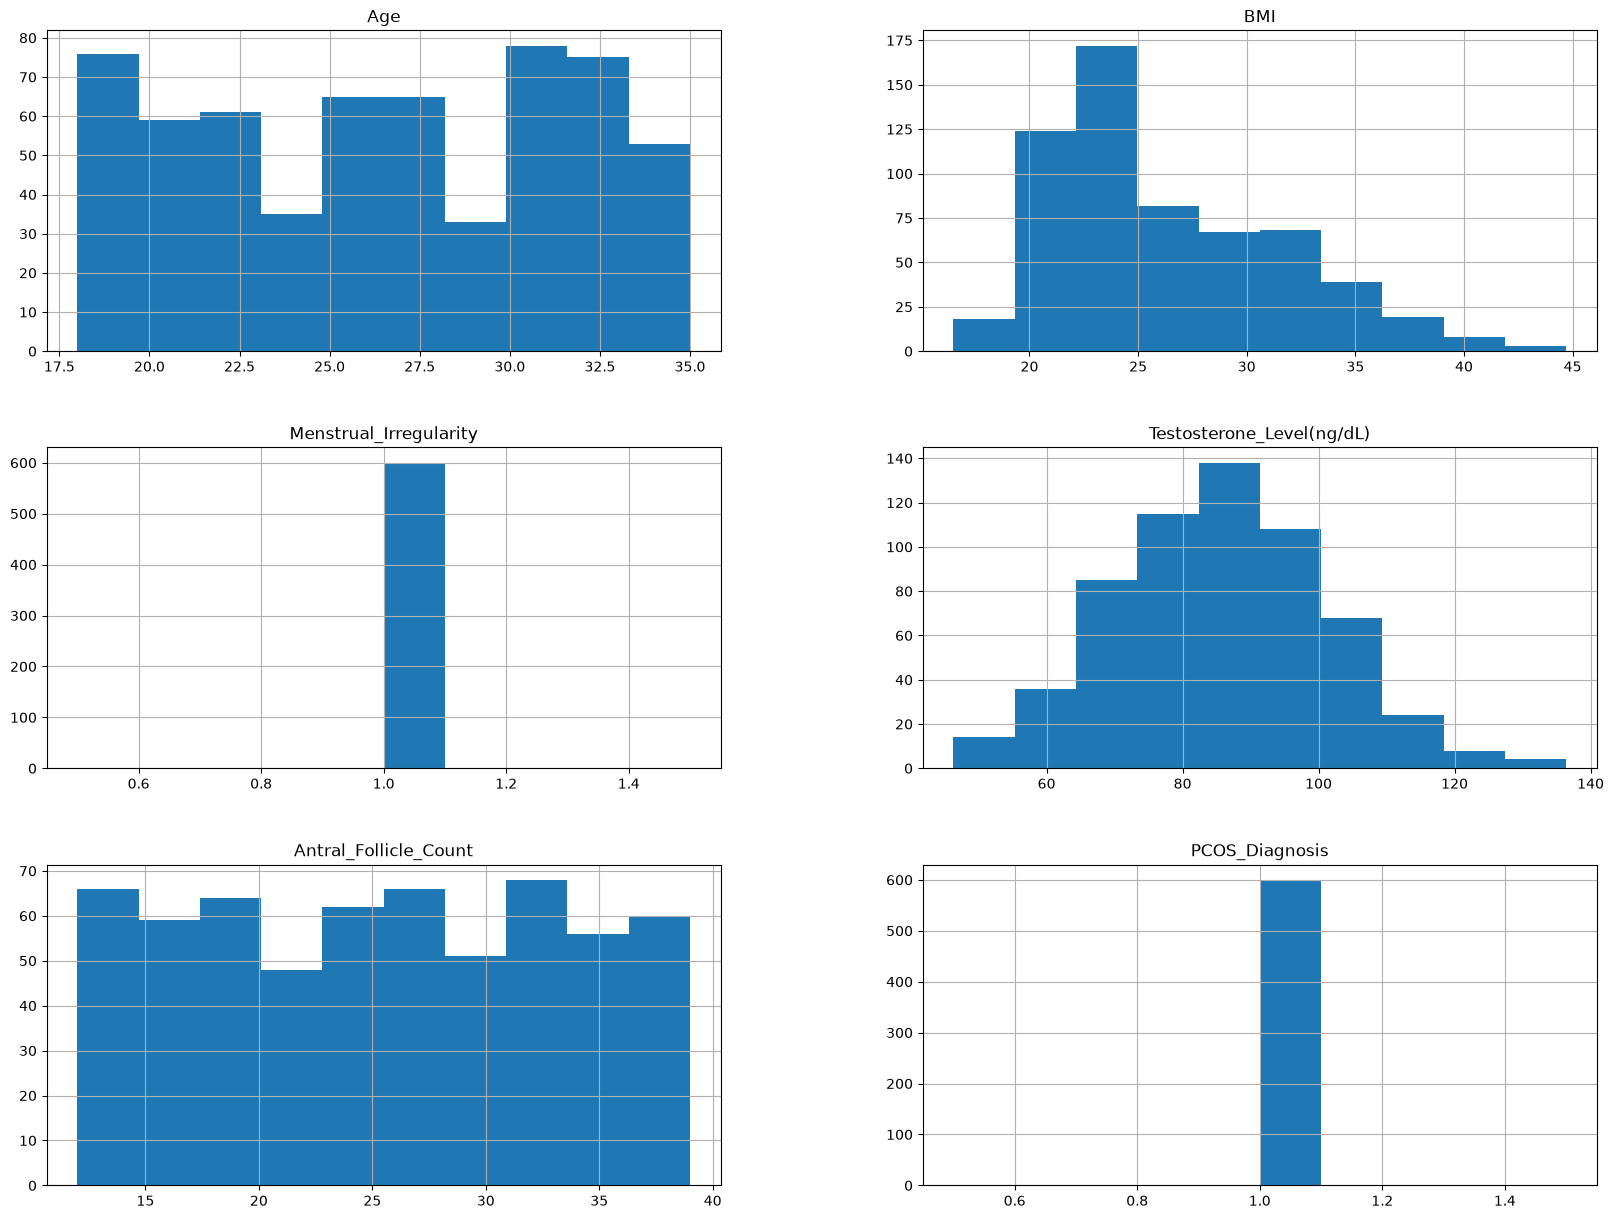

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
dataset.where(dataset['PCOS_Diagnosis'] == 1).hist(figsize=(20,15))

array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Menstrual_Irregularity'}>,
        <Axes: title={'center': 'Testosterone_Level(ng/dL)'}>],
       [<Axes: title={'center': 'Antral_Follicle_Count'}>,
        <Axes: title={'center': 'PCOS_Diagnosis'}>]], dtype=object)

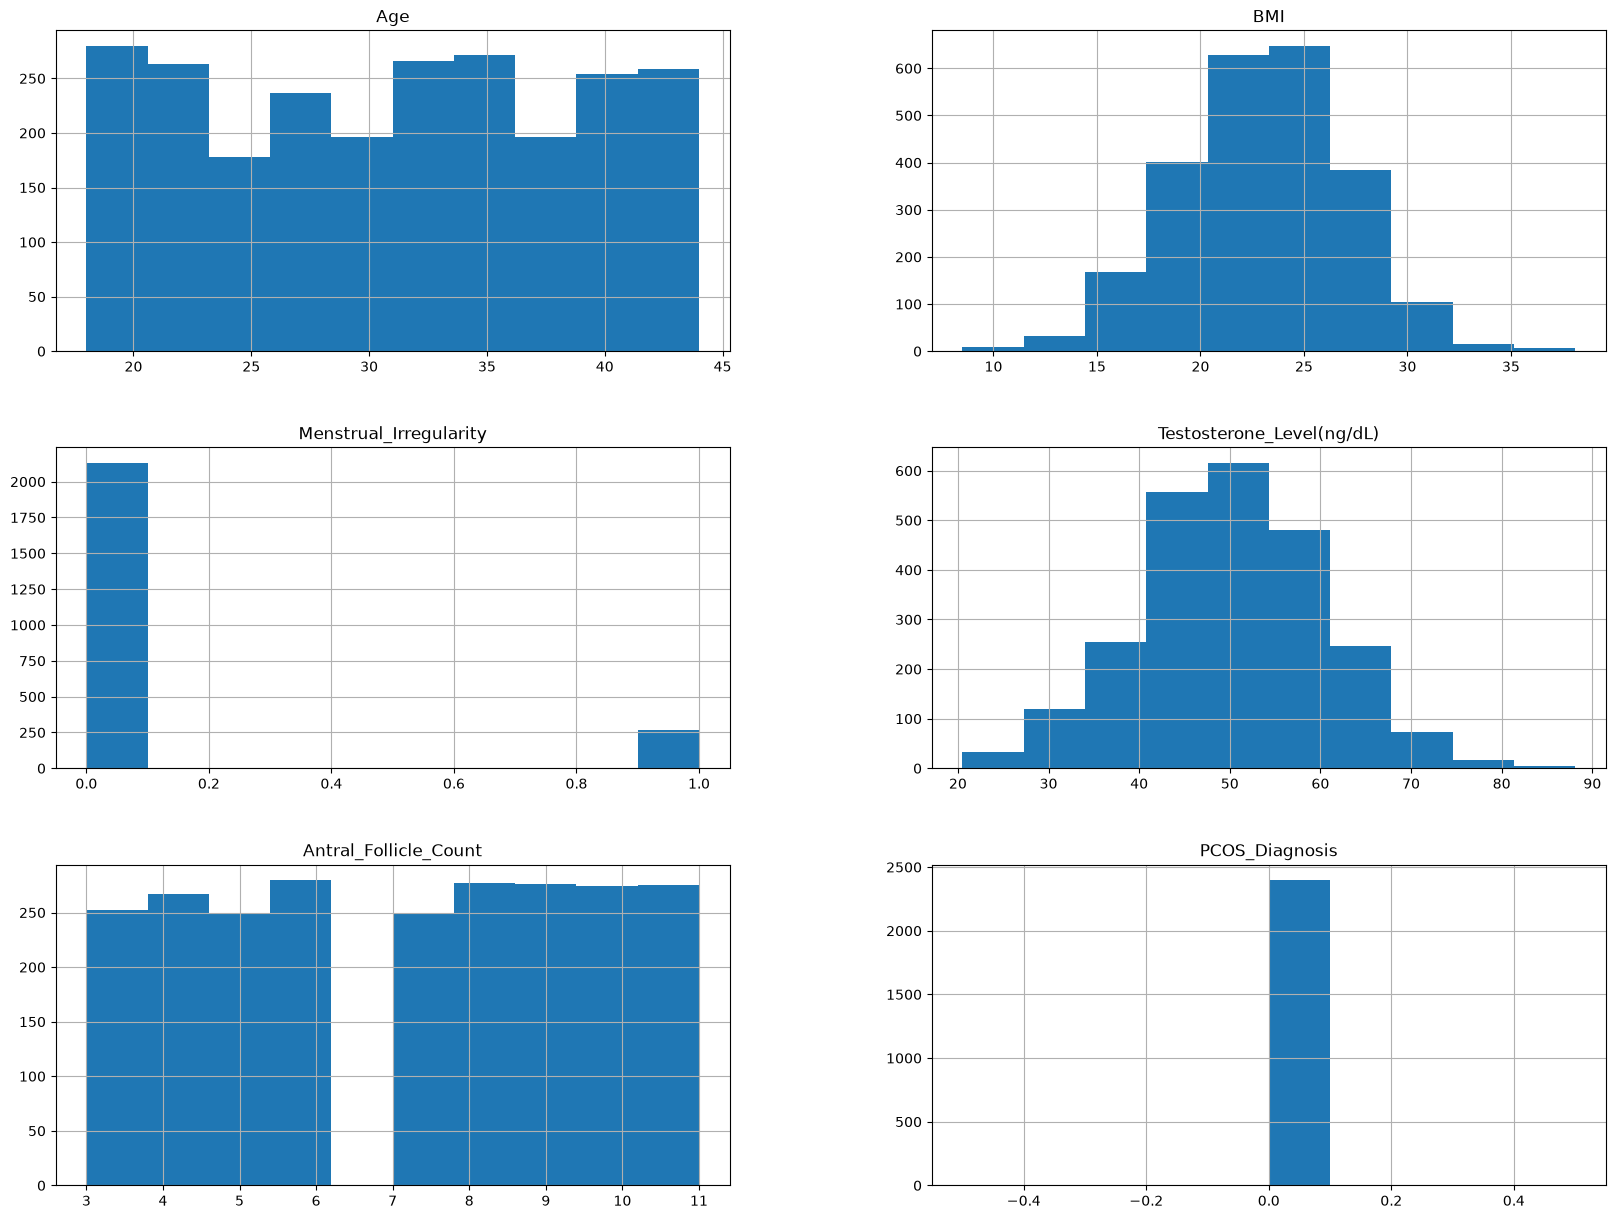

In [12]:
dataset.where(dataset['PCOS_Diagnosis'] == 0).hist(figsize=(20,15))

In [13]:
dataset['age_cat'] = np.ceil(dataset['Age'])

dataset['age_cat'].where(dataset['age_cat'] < 10, 10.0, inplace=True)

/tmp/ipykernel_184949/356731043.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['age_cat'].where(dataset['age_cat'] < 10, 10.0, inplace=True)


0       10
1       10
2       10
3       10
4       10
        ..
2995    10
2996    10
2997    10
2998    10
2999    10
Name: age_cat, Length: 3000, dtype: int64

In [14]:
dataset['age_cat'] = pd.cut(
    dataset['Age'], 
    bins=[10, 20, 30, 40, 50, np.inf],
    labels=[10, 20, 30, 40, 50]
)

dataset['age_cat2'] = pd.cut(
    dataset['Age'], 
    bins=[10, 20, 30, 40, 50, np.inf]
)

In [15]:
dataset['age_cat2'].value_counts()

age_cat2
(20.0, 30.0]    1207
(30.0, 40.0]    1063
(10.0, 20.0]     382
(40.0, 50.0]     348
(50.0, inf]        0
Name: count, dtype: int64

<Axes: >

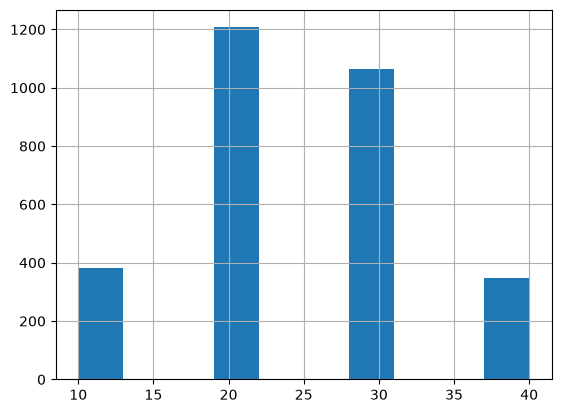

In [16]:
dataset['age_cat'].hist()

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for train_index, test_index in split.split(dataset, dataset["Age"]):
    strat_train_set = dataset.loc[train_index]
    strat_test_set = dataset.loc[test_index]

In [18]:
strat_test_set["Age"].value_counts() / len(strat_test_set)

Age
30    0.048000
33    0.046667
18    0.046000
25    0.042667
31    0.042000
29    0.042000
20    0.042000
21    0.042000
34    0.041333
24    0.040667
22    0.040000
19    0.039333
35    0.038667
28    0.038667
32    0.038000
23    0.037333
27    0.036667
26    0.034667
38    0.034000
42    0.032667
37    0.031333
39    0.029333
41    0.029333
44    0.028000
36    0.027333
40    0.026000
43    0.025333
Name: count, dtype: float64

In [19]:
strat_test_set["Age"].value_counts() / len(strat_train_set)

Age
30    0.048000
33    0.046667
18    0.046000
25    0.042667
31    0.042000
29    0.042000
20    0.042000
21    0.042000
34    0.041333
24    0.040667
22    0.040000
19    0.039333
35    0.038667
28    0.038667
32    0.038000
23    0.037333
27    0.036667
26    0.034667
38    0.034000
42    0.032667
37    0.031333
39    0.029333
41    0.029333
44    0.028000
36    0.027333
40    0.026000
43    0.025333
Name: count, dtype: float64

In [20]:
dataset["Age"].value_counts() / len(dataset)

Age
30    0.048333
33    0.046667
18    0.046333
25    0.042333
29    0.041667
20    0.041667
21    0.041667
31    0.041667
34    0.041667
24    0.040667
22    0.040000
19    0.039333
35    0.038667
28    0.038667
32    0.037667
23    0.037333
27    0.036667
26    0.035000
38    0.034000
42    0.032667
37    0.031333
41    0.029667
39    0.029333
44    0.028000
36    0.027667
40    0.025667
43    0.025667
Name: count, dtype: float64

In [21]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("age_cat", axis=1, inplace=True)
    set_.drop("age_cat2", axis=1, inplace=True)

<Axes: xlabel='Age', ylabel='Testosterone_Level(ng/dL)'>

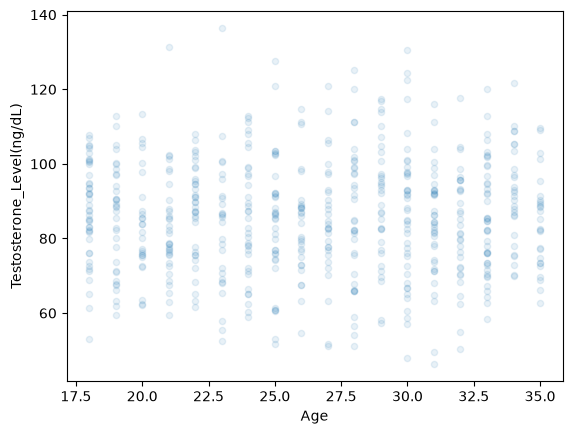

In [22]:
dataset.where(dataset['PCOS_Diagnosis'] == 1).plot(kind="scatter", x="Age", y="Testosterone_Level(ng/dL)", alpha=0.1)

<Axes: xlabel='Age', ylabel='Testosterone_Level(ng/dL)'>

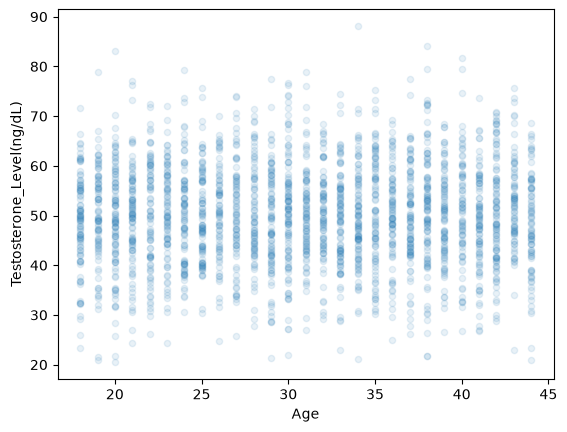

In [23]:
dataset.where(dataset['PCOS_Diagnosis'] == 0).plot(kind="scatter", x="Age", y="Testosterone_Level(ng/dL)", alpha=0.1)